In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Operator
from qiskit_dynamics import Solver
from qiskit_dynamics.pulse import InstructionToSignals
import qiskit.pulse as pulse
import warnings
warnings.filterwarnings('ignore')
from scipy.optimize import minimize_scalar
import sympy as sym



In [2]:
#construct a Gaussian square pulse
def lifted_gaussian(
    t: sym.Symbol,
    center,
    t_zero,
    sigma,
) -> sym.Expr:
    t_shifted = (t - center).expand()
    t_offset = (t_zero - center).expand()

    gauss = sym.exp(-((t_shifted / sigma) ** 2) / 2)
    offset = sym.exp(-((t_offset / sigma) ** 2) / 2)

    return (gauss - offset) / (1 - offset)


sigma=10.0
def gaussian_square_generated_by_pulse(sigma, width):

    
    _t, _duration, _amp, _sigma, _width, _angle = sym.symbols(
        "t, duration, amp, sigma, width, angle"
    )
    _center = _duration / 2

    _sq_t0 = _center - _width / 2
    _sq_t1 = _center + _width / 2

    _gaussian_ledge = lifted_gaussian(_t, _sq_t0, -1, _sigma)
    _gaussian_redge = lifted_gaussian(_t, _sq_t1, _duration + 1, _sigma)

    envelope_expr = (
        _amp
        * sym.exp(sym.I * _angle)
        * sym.Piecewise(
            (_gaussian_ledge, _t <= _sq_t0), (_gaussian_redge, _t >= _sq_t1), (1, True)
        )
    )

    # we need to set disable_validation True to enable jax-jitting.
    pulse.ScalableSymbolicPulse.disable_validation = True

    return pulse.ScalableSymbolicPulse(
            pulse_type="GaussianSquare",
            duration=230,
            amp=1,
            angle=0,
            parameters={"sigma": sigma, "width": width},
            envelope=envelope_expr,
            constraints=sym.And(_sigma > 0, _width >= 0, _duration >= _width),
            valid_amp_conditions=sym.Abs(_amp) <= 1.0,
        )



#Build the pulse and convert it into signal 
def build_gs_pulse(sigma, width):
    instance = gaussian_square_generated_by_pulse(sigma, width)
    with pulse.build() as Xp:
        pulse.play(instance, pulse.DriveChannel(0))
    return Xp, instance

def convert_gs_into_signal(Xp):
    converter = InstructionToSignals(dt, carriers={"d0": v})
    signal = converter.get_signals(Xp)

    return signal
    

In [3]:
#Onjective (what i optimize is the parameter/parameters that the objective gets as input)

X_op = Operator.from_label('X').data
print(f'σx: {X_op}') 
Y_op=Operator.from_label('Y').data
print(f'σy: {Y_op}')


def fidelity(U):
    return np.abs(np.trace(X_op.conj().T @ U))**2 / 4

v = 5.     #freq
r = 0.02    #drive strength
dt = 0.222

static_hamiltonian = 2 * np.pi * v * Operator.from_label('Z') / 2    #H0(t)=2pv*Z/2 
drive_term = 2 * np.pi * r * Operator.from_label('X') / 2            #Hd(t)=2prs(t)*X/2
hamiltonian_solver = Solver(
    static_hamiltonian=static_hamiltonian,
    hamiltonian_operators=[drive_term],
    hamiltonian_channels=["d0"],
    channel_carrier_freqs={"d0": v},
    rotating_frame=static_hamiltonian,
    dt=dt,
)




def objective(width):
    #sigma, width=params
    Xp, instance=build_gs_pulse(sigma, width)
    signal=convert_gs_into_signal(Xp)
    result = hamiltonian_solver.solve(
        y0=np.eye(2, dtype=complex),
        t_span=[0, instance.duration * dt],
        signals=[signal],
        atol=1e-8,
        rtol=1e-8
    )
    return 1. - fidelity(result[0].y[-1])





σx: [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
σy: [[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]


In [4]:
#run optimization (without jax)
res = minimize_scalar(
    objective,
    bounds=(0.0, 200.0),   # width must be <= duration
    method="bounded",
    options={"xatol": 1e-2}
)

'''import scipy
duration=230
initial_params = np.array([10,10])

smin=2
smax=duration//4
res=scipy.optimize.minimize(
    objective,
    x0=initial_params,
    bounds=[(smin, smax), (0, 200.0)]
)
'''

optimal_width = res.x
optimal_fidelity = 1.0 - res.fun

print("Optimal width:", optimal_width)
print("Optimal fidelity:", optimal_fidelity)



print(res.message)
print('Number of function evaluations: ' + str(res.nfev))
print('Function value: ' + str(res.fun))


Optimal width: 199.99516502988985
Optimal fidelity: 0.9978187433525164
Solution found.
Number of function evaluations: 22
Function value: 0.002181256647483587


In [ ]:
#plots and checks
print("Initial fidelity:", 1.0 - objective(10.0))
print("Final fidelity:", 1.0 - objective(optimal_width))



widths = np.linspace(0, 230, 60)
fids = [1 - objective(w) for w in widths]

plt.figure()
plt.plot(widths, fids, "o-")
plt.xlabel("width")
plt.ylabel("X-gate fidelity")
plt.show()



Initial fidelity: 0.058628926392855885
Final fidelity: 0.9978187433525164


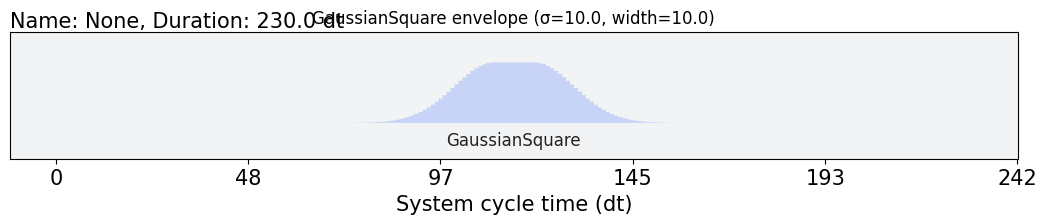

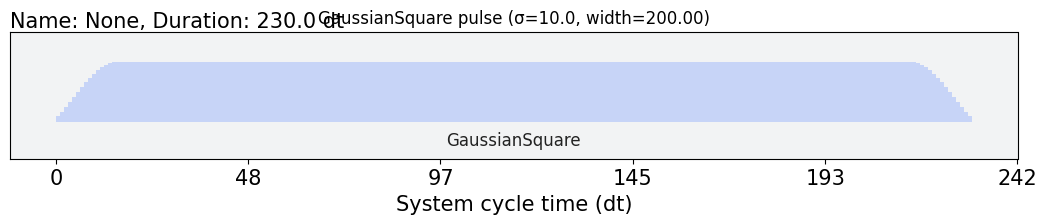

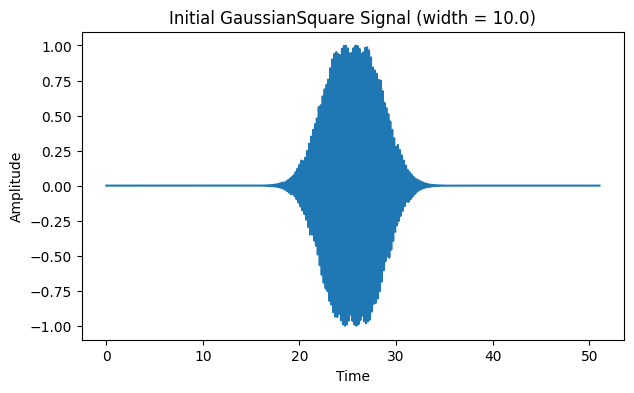

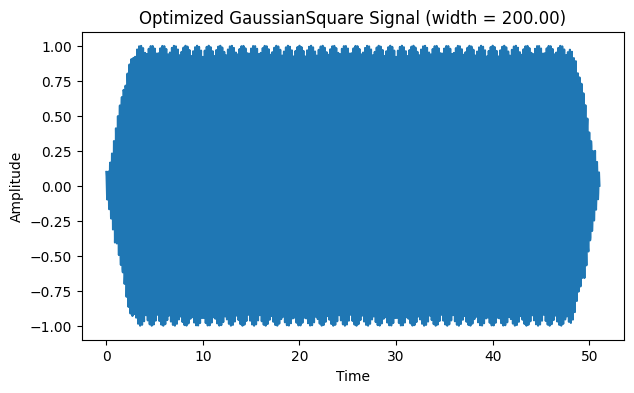

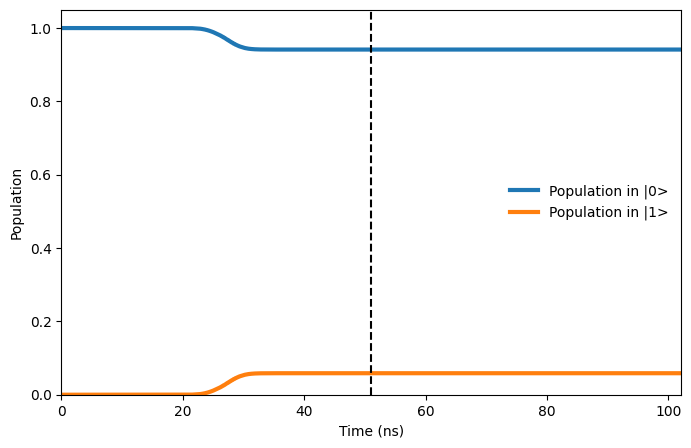

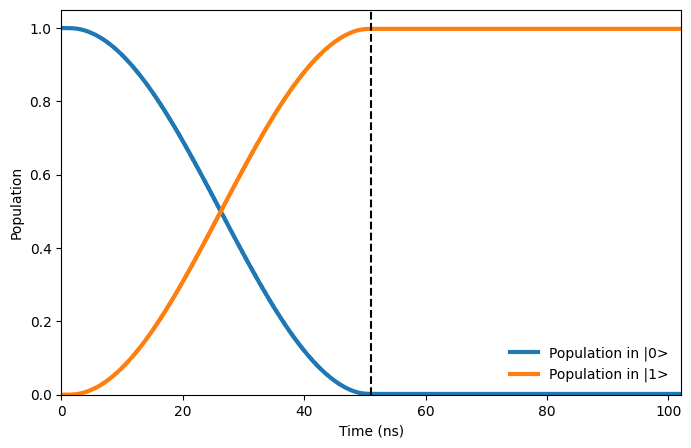

In [21]:
%matplotlib inline
def plot_env_initial_optimized():
    initial_pulse=gaussian_square_generated_by_pulse(sigma, 10.0).draw()
    plt.gca().set_title(f"GaussianSquare envelope (σ={sigma}, width=10.0)")
    plt.show()
    
    
    opt_pulse=gaussian_square_generated_by_pulse(sigma, optimal_width).draw()
    plt.title(f"GaussianSquare pulse (σ={sigma}, width={optimal_width:.2f})")
    plt.show()


def plot_signal_inital_optimized():
    
    Xp, instance=build_gs_pulse(sigma, 10.0)
    signals=convert_gs_into_signal(Xp)
    fig, ax = plt.subplots(figsize=(7,4))
    signals[0].draw(0, instance.duration * dt, 2000, axis=ax)
    ax.set_title(f"Initial GaussianSquare Signal (width = 10.0)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Amplitude")
    plt.show()


    
    Xp_opt, instance_opt=build_gs_pulse(sigma, optimal_width)
    signals_opt=convert_gs_into_signal(Xp_opt)
    fig, ax = plt.subplots(figsize=(7,4))
    signals_opt[0].draw(0, instance_opt.duration * dt, 2000, axis=ax)
    ax.set_title(f"Optimized GaussianSquare Signal (width = {optimal_width:.2f})")
    ax.set_xlabel("Time")
    ax.set_ylabel("Amplitude")
    plt.show()

    plot_populs_initial_optimized(instance, instance_opt, Xp, Xp_opt)

    
from qiskit.quantum_info.states import Statevector

y0 = Statevector([1., 0.])

def plot_populs_initial_optimized(inst, inst_opt, sign, sign_opt):
    
    result=hamiltonian_solver.solve(
        y0=y0,
        t_span=[0, 2*inst.duration * dt],
        signals=sign, atol=1e-8, rtol=1e-8
    )

    result_opt = hamiltonian_solver.solve(
        y0=y0,
        t_span=[0, 2*inst_opt.duration * dt],
        signals=sign_opt,
        atol=1e-8, rtol=1e-8
    )
    U=result.y[-1]
    U_opt = result_opt.y[-1]
    T = inst.duration * dt

  
    plot_populations(result, T)
    plot_populations(result_opt, T)


def plot_populations(sol,T,title=None):
    pop0 = [psi.probabilities()[0] for psi in sol.y]
    pop1 = [psi.probabilities()[1] for psi in sol.y]

    fig = plt.figure(figsize=(8, 5))
    plt.plot(sol.t, pop0, lw=3, label="Population in |0>")
    plt.plot(sol.t, pop1, lw=3, label="Population in |1>")
    plt.xlabel("Time (ns)")
    plt.ylabel("Population")
    plt.legend(frameon=False)
    plt.ylim([0, 1.05])
    plt.xlim([0, 2*T])
    plt.vlines(T, 0, 1.05, "k", linestyle="dashed")
    if title:
        plt.title(title)
    plt.show()

plot_env_initial_optimized()
plot_signal_inital_optimized()
